# Word diagrams: `WordGraph`, faces, regions

The diagram layer of `DiagrammaticHecke.jl`. A `WordGraph` is a planar Soergel
diagram in a disc: the boundary is a circular word, the interior holds nodes
(`:dot`, `:trivalent`, `:braid`) with a FIXED number of arms, connected by
coloured edges. Every diagram in a notebook cell is drawn (Tutte layout;
browser Jupyter shows SVG, VS Code the PNG).

In [1]:
using DiagrammaticHecke
debug_labels(true)   # arm/leaf numbers in every picture

true

## 1. Generators

`dot(i)`, `trivalent(i)` and `braid(i, j; m)` build the generating diagrams;
`Leaf`/`NodePort`/`Edge` wire arbitrary ones by hand. The boundary is read
counter-clockwise, node arms clockwise — `check_wiring` verifies exactly this
convention, and `euler(g) == 2` is the global planarity test.

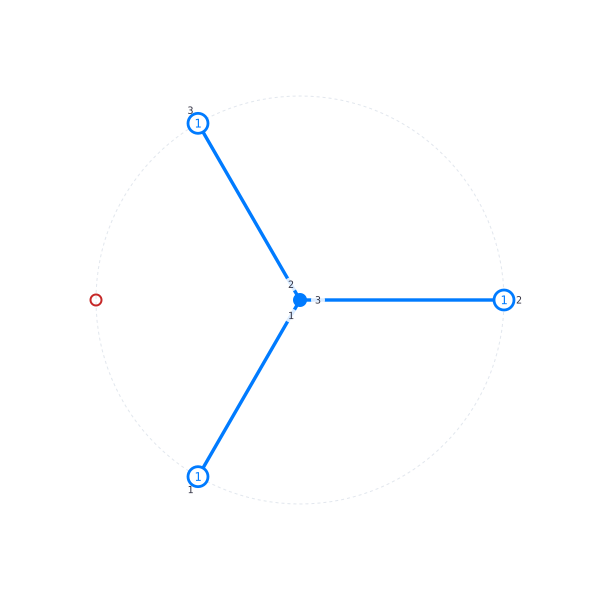

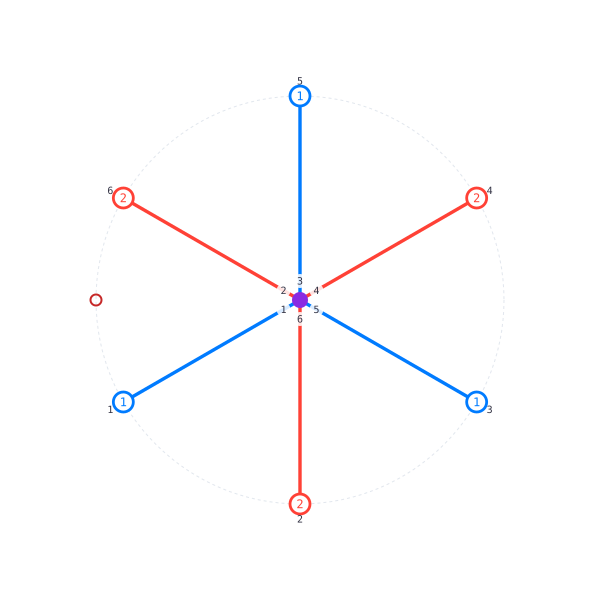

euler(b) = 2
is_planar_embedding(b) = true
isempty(check_wiring(b)) = true


In [2]:
t = trivalent(1)
display(t)
b = braid(1, 2; m = 3)
display(b)
@show euler(b) is_planar_embedding(b) isempty(check_wiring(b));

## 2. Named example graphs

`diagram/Fixtures.jl` collects the small named diagrams used throughout the
tests: `unit_graph`, `needle_a_graph`, `barbell_graph`, `r3_braid_dot`, …

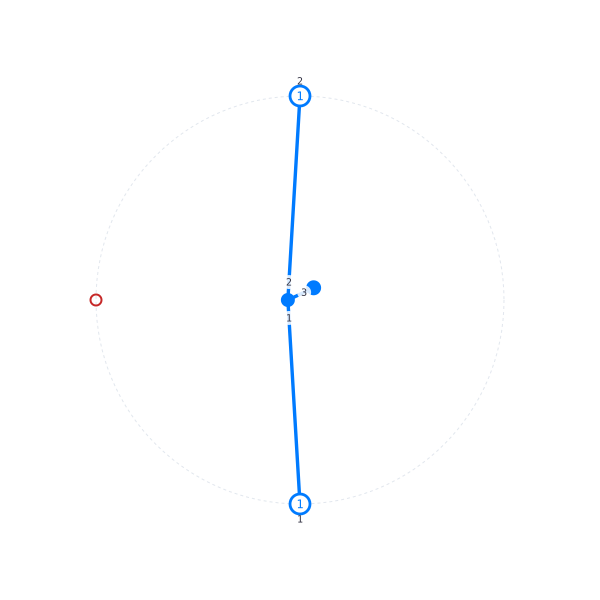

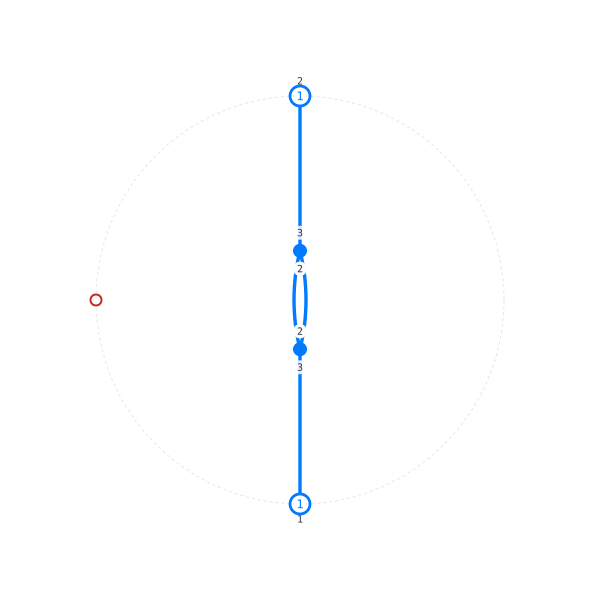

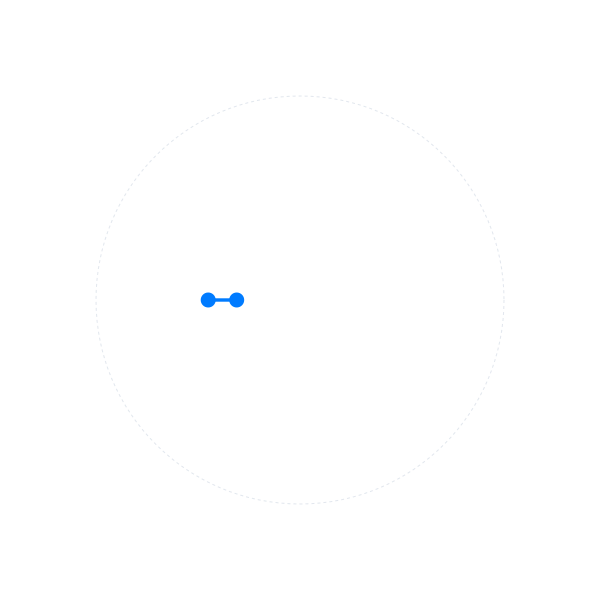

In [3]:
display(unit_graph())
display(needle_a_graph())
display(barbell_graph())

## 3. Faces and regions

Two parallel notions: `face_count` counts faces of the planar embedding, while
`region_count` treats the boundary as a wall and counts what the picture shows
as separate areas (regions REFINE faces). A dot merges its two neighbouring
boundary gaps; a leaf-to-leaf chord is a wall. Region labels later carry the
polynomial decorations.

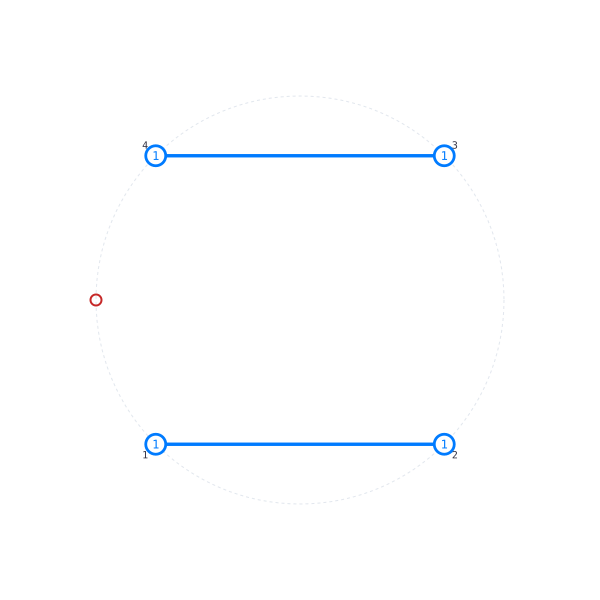

face_count(str) = 3
region_count(str) = 3
boundary_regions(str) = [[1], [2, 4], [3]]


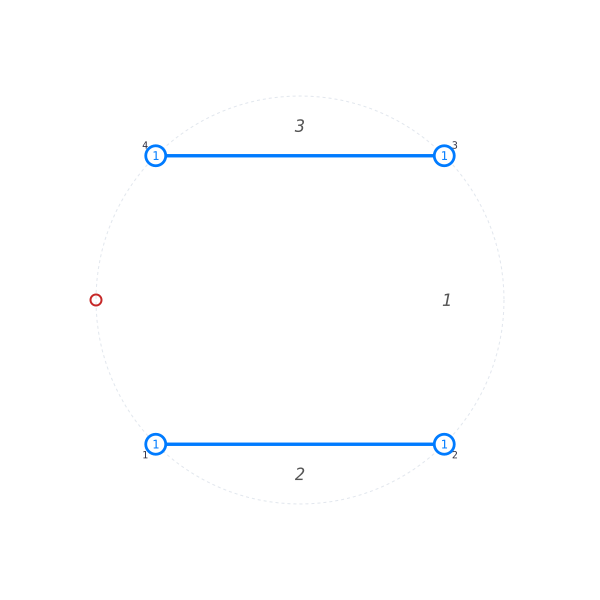

In [4]:
str = WordGraph(CircularWord([1,1,1,1]), Node[],
                Edge[Edge(1, Leaf(1), Leaf(2)), Edge(1, Leaf(3), Leaf(4))])
display(str)
@show face_count(str) region_count(str) boundary_regions(str)
display_cell_number(str)   # cell ids drawn into the picture

## 4. Morphism view and marker distances

A `MorphismGraph` is a `WordGraph` plus two cuts splitting the boundary into
bottom and top. The cut carries the black boundary marker; `cell_distances`
are BFS levels of the cells measured from it — the notion the scalar-extraction
rule (distance 0) is built on.

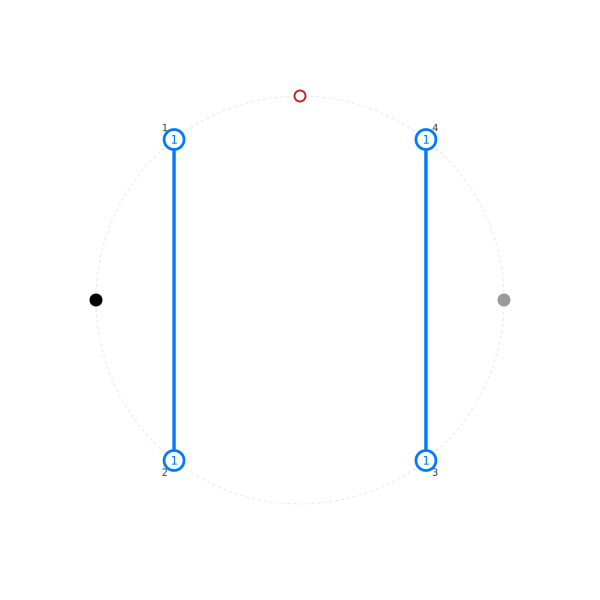

bottom(m) = [1, 1]
top(m) = [1, 1]
cell_distances(m) = [1, 0, 2]


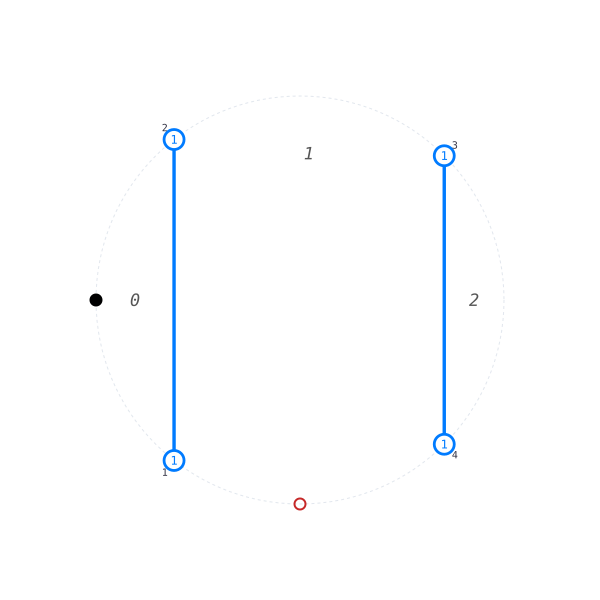

In [5]:
m = morphism_graph(str, 1, 3)      # bottom = 11, top = 11
display(m)
@show bottom(m) top(m) cell_distances(m)
display_cell_distance(m)

## 5. Saving and loading

Every diagram round-trips through a small versioned, line-based text format. It
is meant to be committed: a diagram in a repository should be readable and
reviewable, not a blob. `.wg` holds a `WordGraph`, `.wgm` a `MorphismGraph` —
the same format with the cuts written on one extra line.

A port is `L<k>` for boundary leaf `k`, `n<node>.<slot>` for a node connector,
or `C<colour>` for a free circle.

In [6]:
print(wordgraph_to_string(unit_graph()))

#wg 2
word 11
# nodes
n trivalent 1
n dot 1
# edges
e 1 L1 n1.1
e 1 L2 n1.2
e 1 n1.3 n2.1


`wordgraph_from_string` reads it back. The round trip is the test that the format loses nothing.

In [7]:
g  = barbell_graph()
g2 = wordgraph_from_string(wordgraph_to_string(g))
@show canonical_key(g) == canonical_key(g2);

canonical_key(g) == canonical_key(g2) = true


A `MorphismGraph` carries the two cuts through the same format.

In [8]:
m  = morphism_graph(str, 1, 3)
print(morphismgraph_to_string(m))
m2 = morphismgraph_from_string(morphismgraph_to_string(m))
@show bottom(m2) == bottom(m) top(m2) == top(m);

#wg 2
word 1111
# nodes
# edges
e 1 L1 L2
e 1 L3 L4
cuts 1 3
bottom(m2) == bottom(m) = true
top(m2) == top(m) = true


Several diagrams go in one file, separated by `---`, each with a
free-form metadata comment that is preserved verbatim. `save_morphisms` and
`load_morphisms` handle that container; the comment is where a recipe such as
`e=1,1,0 f=1,0,1 z=1 degree=2` lives.

In [9]:
path = joinpath(mktempdir(), "leaves.wgm")
entries = [MorphismEntry("# e=$(d.e) f=$(d.f) degree=$(d.degree)", d.morphism)
           for d in double_leaves([1,2], [1,2])]
save_morphisms(path, entries)
back = load_morphisms(path)
@show length(back) back[1].meta
println(read(path, String)[1:200], "…")

length(back) = 4
(back[1]).meta = "e=[0, 0] f=[0, 0] degree=4"
# e=[0, 0] f=[0, 0] degree=4
#wg 2
word 1122
# nodes
n dot 1
n dot 2
n dot 1
n dot 2
# edges
e 1 L1 n1.1
e 2 L2 n2.1
e 1 L4 n3.1
e 2 L3 n4.1
cuts 0 2
---
# e=[1, 0] f=[1, 0] degree=2
#wg 2
word 1122
#…
